## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the road characteristics and this using the LST computed step-by-step.

In [59]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [60]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [61]:
lst_path = PROCESSED_DIR /'lstcalcsummer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstcalcsummer_bang.csv


In [62]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [63]:
df_lst_mean_summer.head()

,system:index,ward_name,mean,ward_id
0,0,25 - Vinayaka Layout,40.063313,25
1,1,2 - Aerocity,39.422320,2
2,2,3 - Chowdeshwari ward,39.380856,3
3,3,15 - Ramamurthy Nagara,39.406186,15
4,4,58 - Nagashettyhalli,38.373896,58


In [64]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 36.44786789054648.
The maximum temperature is 43.20688102882611.


### Road density

In [65]:
road_density_path = PROCESSED_DIR /'results_bangalore_all_roads.csv'
df_road_density = pd.read_csv(road_density_path)

In [66]:
df_road_density.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,street_length,street_density,area
0,0,25,25 - Vinayaka Layout,West,75687.559355,29390.911807,2.575203e+06
1,1,2,2 - Aerocity,North,124800.280922,12164.886655,1.025906e+07
2,2,3,3 - Chowdeshwari ward,North,102396.516478,15924.039220,6.430310e+06
3,3,15,15 - Ramamurthy Nagara,East,22700.859701,28293.603033,8.023319e+05
4,4,58,58 - Nagashettyhalli,North,25813.225031,27016.836493,9.554496e+05


In [67]:
merged = pd.merge(df_lst_mean_summer, df_road_density, on='ward_name')
merged.head()

,system:index,ward_name,mean,ward_id_x,Unnamed: 0,ward_id_y,Corporatio,street_length,street_density,area
0,0,25 - Vinayaka Layout,40.063313,25,0,25,West,75687.559355,29390.911807,2.575203e+06
1,1,2 - Aerocity,39.422320,2,1,2,North,124800.280922,12164.886655,1.025906e+07
2,2,3 - Chowdeshwari ward,39.380856,3,2,3,North,102396.516478,15924.039220,6.430310e+06
3,3,15 - Ramamurthy Nagara,39.406186,15,3,15,East,22700.859701,28293.603033,8.023319e+05
4,4,58 - Nagashettyhalli,38.373896,58,4,58,North,25813.225031,27016.836493,9.554496e+05


Only retain the relevant variables and rename:

In [68]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio', 'street_length', 'street_density', 'area']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio,street_length,street_density,area
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05


In [69]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05


In [70]:
print(f'The mininim street density is {merged["street_density"].min()} metres or {merged["street_density"].min()/1000} km per square km.')
print(f'The maximimum street density is {merged["street_density"].max()} metres or {merged["street_density"].max()/1000} km per square km.')

The mininim street density is 9898.12631486204 metres or 9.89812631486204 km per square km.
The maximimum street density is 43516.131293869774 metres or 43.516131293869776 km per square km.


In [71]:
# index of min and max street density
idx_min = merged["street_density"].idxmin()
idx_max = merged["street_density"].idxmax()

In [72]:
# ward names
ward_min = merged.loc[idx_min, "ward_name"]
ward_max = merged.loc[idx_max, "ward_name"]

In [73]:
print(f' The ward with the minimum street density is {ward_min} and the maximum street density is {ward_max}.')

 The ward with the minimum street density is 27 - Vibhootipura and the maximum street density is 53 - Rayapuram.


#### Street density

In [74]:
fig_path = IMAGES_DIR / 'regression_bangalore_street_density_calc.png'

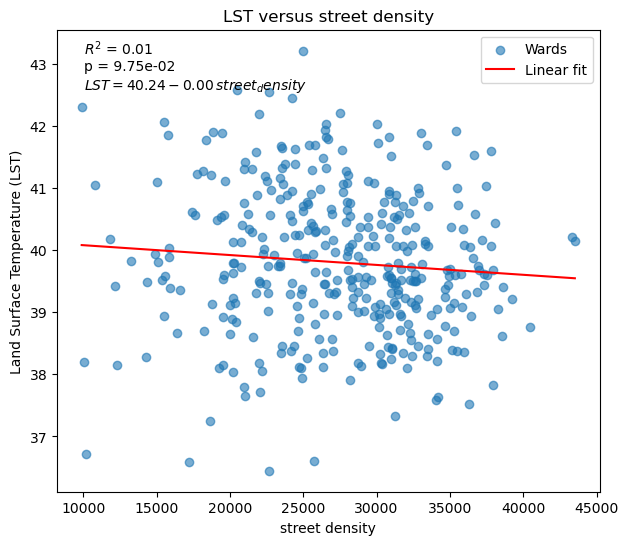

In [75]:
# x and y
x = merged["street_density"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("street density")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus street density")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,street_density$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [76]:
p_value

np.float64(0.09754584709602367)

In [77]:
print(slope, intercept, r_value)

-1.5888665900829623e-05 40.23639576646089 -0.08638497259564636


In [78]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.08638497259564633), pvalue=np.float64(0.09754584709602408))

In [79]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['street_density']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.759
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0975
Time:                        23:30:12   Log-Likelihood:                -576.12
No. Observations:                 369   AIC:                             1156.
Df Residuals:                     367   BIC:                             1164.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             40.2364      0.269    149.

In [80]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.08638497259564633), pvalue=np.float64(0.09754584709602408))

#### Straightness

In [81]:
straightness_path = PROCESSED_DIR /'results_bangalore_straightness_all_roads.csv'
df_straightness = pd.read_csv(straightness_path)

In [82]:
df_straightness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
0,0,25,25 - Vinayaka Layout,West,0.722825
1,1,2,2 - Aerocity,North,0.644505
2,2,3,3 - Chowdeshwari ward,North,0.681202
3,3,15,15 - Ramamurthy Nagara,East,0.697888
4,4,58,58 - Nagashettyhalli,North,0.666402


In [83]:
merged = pd.merge(merged, df_straightness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,Unnamed: 0,ward_id_y,Corporatio,straightness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0,25,West,0.722825
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,1,2,North,0.644505
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,2,3,North,0.681202
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,3,15,East,0.697888
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,4,58,North,0.666402


In [84]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402


In [85]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402


In [86]:
# x and y
x = merged["straightness"]
y = merged["mean_lst"]

In [87]:
fig_path = IMAGES_DIR / 'regression_bangalore_straightness_calc.png'

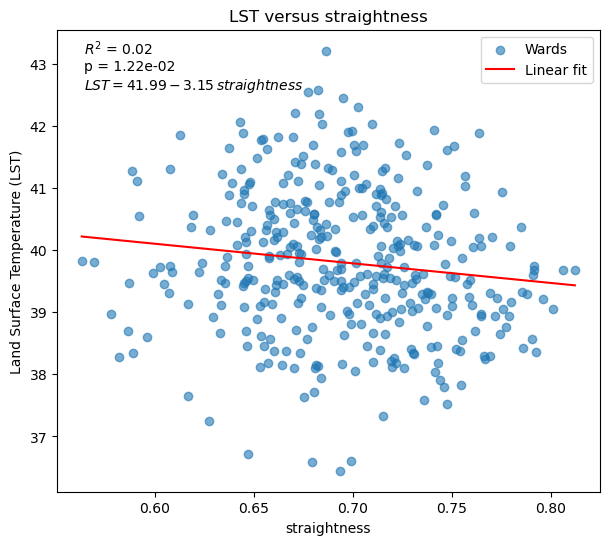

In [88]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("straightness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus straightness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,straightness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [89]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['straightness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6.341
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0122
Time:                        23:30:17   Log-Likelihood:                -574.34
No. Observations:                 369   AIC:                             1153.
Df Residuals:                     367   BIC:                             1160.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           41.9930      0.872     48.132   

In [90]:
pearsonr(merged['straightness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.13032844160951446), pvalue=np.float64(0.012219907671256768))

#### Global closeness

In [91]:
global_closeness_path = PROCESSED_DIR /'results_bangalore_global_closeness_all_roads.csv'
df_global_closeness = pd.read_csv(global_closeness_path)

In [92]:
df_global_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness
0,0,25,25 - Vinayaka Layout,West,0.000769
1,1,2,2 - Aerocity,North,0.000296
2,2,3,3 - Chowdeshwari ward,North,0.000380
3,3,15,15 - Ramamurthy Nagara,East,0.001307
4,4,58,58 - Nagashettyhalli,North,0.001277


In [93]:
merged = pd.merge(merged, df_global_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,Unnamed: 0,ward_id_y,Corporatio,closeness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0,25,West,0.000769
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,1,2,North,0.000296
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,2,3,North,0.000380
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,3,15,East,0.001307
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,4,58,North,0.001277


In [94]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'closeness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,closeness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277


In [95]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'closeness': 'global_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277


In [96]:
# x and y
x = merged["global_closeness"]
y = merged["mean_lst"]

In [97]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [98]:
fig_path = IMAGES_DIR / 'regression_bangalore_global_closeness_calc.png'

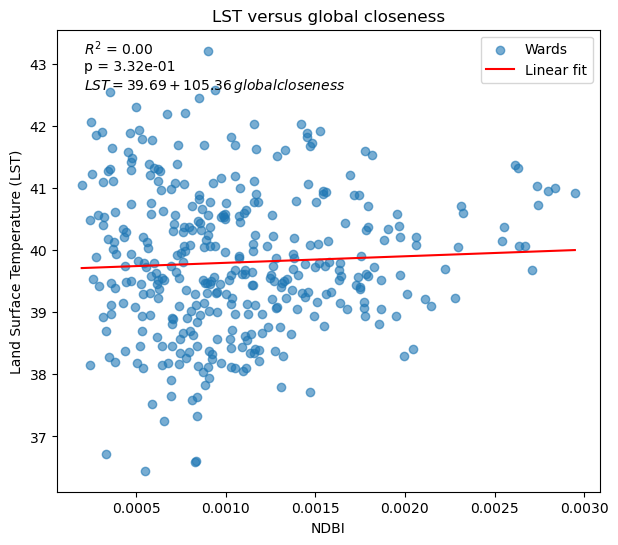

In [99]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus global closeness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,global closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [100]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['global_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9433
Date:                Wed, 14 Jan 2026   Prob (F-statistic):              0.332
Time:                        23:30:22   Log-Likelihood:                -577.02
No. Observations:                 369   AIC:                             1158.
Df Residuals:                     367   BIC:                             1166.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               39.6883      0.131  

In [101]:
pearsonr(merged['global_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.050633731208399764), pvalue=np.float64(0.33206418407393257))

#### Local closeness

In [102]:
local_closeness_path = PROCESSED_DIR /'results_bangalore_local_closeness_all_roads.csv'
df_local_closeness = pd.read_csv(local_closeness_path)
df_local_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness_local
0,0,25,25 - Vinayaka Layout,West,0.000321
1,1,2,2 - Aerocity,North,0.000146
2,2,3,3 - Chowdeshwari ward,North,0.000185
3,3,15,15 - Ramamurthy Nagara,East,0.000882
4,4,58,58 - Nagashettyhalli,North,0.000796


In [103]:
merged = pd.merge(merged, df_local_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,Unnamed: 0,ward_id_y,Corporatio,closeness_local
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769,0,25,West,0.000321
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296,1,2,North,0.000146
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380,2,3,North,0.000185
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307,3,15,East,0.000882
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277,4,58,North,0.000796


In [104]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'global_closeness', 'closeness_local']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,closeness_local
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769,0.000321
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296,0.000146
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380,0.000185
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307,0.000882
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277,0.000796


In [105]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    #'closeness': 'global closeness',
    'closeness_local': 'local_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769,0.000321
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296,0.000146
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380,0.000185
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307,0.000882
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277,0.000796


In [106]:
# x and y
x = merged["local_closeness"]
y = merged["mean_lst"]

In [107]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [108]:
fig_path = IMAGES_DIR / 'regression_bangalore_local_closeness_calc.png'

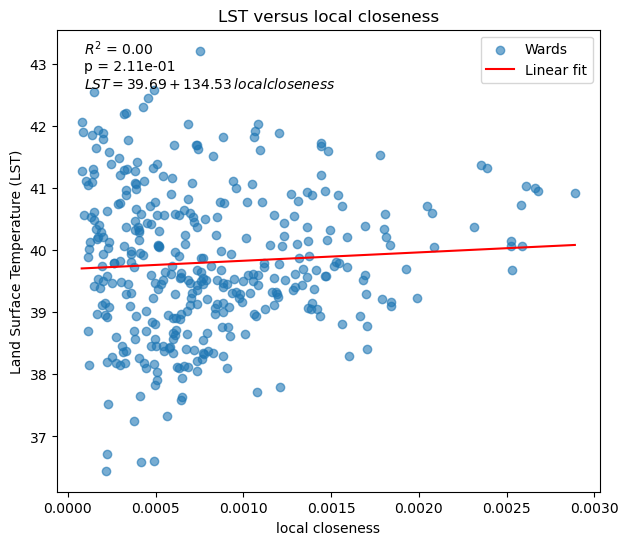

In [109]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("local closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus local closeness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,local closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [110]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['local_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.568
Date:                Wed, 14 Jan 2026   Prob (F-statistic):              0.211
Time:                        23:30:27   Log-Likelihood:                -576.71
No. Observations:                 369   AIC:                             1157.
Df Residuals:                     367   BIC:                             1165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              39.6924      0.106    3

In [111]:
pearsonr(merged['local_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.06522610408474916), pvalue=np.float64(0.21128749365164806))

In [112]:
merged

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,25 - Vinayaka Layout,40.063313,25,West,75687.559355,29390.911807,2.575203e+06,0.722825,0.000769,0.000321
1,2 - Aerocity,39.422320,2,North,124800.280922,12164.886655,1.025906e+07,0.644505,0.000296,0.000146
2,3 - Chowdeshwari ward,39.380856,3,North,102396.516478,15924.039220,6.430310e+06,0.681202,0.000380,0.000185
3,15 - Ramamurthy Nagara,39.406186,15,East,22700.859701,28293.603033,8.023319e+05,0.697888,0.001307,0.000882
4,58 - Nagashettyhalli,38.373896,58,North,25813.225031,27016.836493,9.554496e+05,0.666402,0.001277,0.000796
...,...,...,...,...,...,...,...,...,...,...
364,56 - Gopalpura,40.050300,56,Central,35744.795749,28128.275219,1.270778e+06,0.668262,0.000881,0.000521
365,57 - Cottonpete,41.606664,57,Central,26427.639618,27655.070003,9.556164e+05,0.747517,0.001330,0.001096
366,54 - Binnypete,40.549969,54,Central,13460.033232,28211.384851,4.771135e+05,0.592171,0.001074,0.001290
367,47 - IPD Salappa Ward,40.062125,47,Central,14754.219527,29909.713090,4.932919e+05,0.714489,0.001231,0.001219


## Correlation

In [113]:
vars_df = merged[[
    "mean_lst",
    "street_density",
    "straightness",
    "global_closeness",
    "local_closeness"
]].dropna()

In [114]:
corr = vars_df.corr(method="pearson")

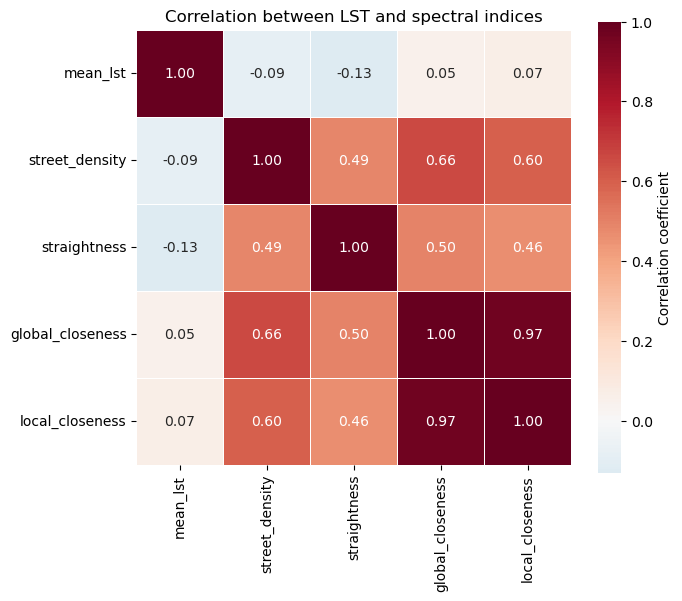

In [115]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_calc.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()